# 4.6 F) Analisis Critico de Estabilidad

Cierra la seccion F del enunciado con dos analisis sobre la matriz final de 4.5 (z-score):

1. **Data leakage (protocolo pareado multi-seed):** la pipeline completa (seleccion canonica de columnas -> z-score) se reajusta SOLO con el set de entrenamiento y se compara contra la version con fuga (parametros ajustados sobre las 452 filas). El brazo sin fuga calcula la seleccion de columnas y (mu, sigma) exclusivamente en train; el brazo con fuga los calcula en el dataset completo. Se repite en 15 splits estratificados y se reporta la diferencia pareada de MSE de test y el porcentaje de splits optimistas.
2. **Convergencia del descenso de gradiente:** GD con paso seguro eta = 1/L (L = mayor autovalor de X'X/n) sobre la matriz centrada (unidades originales) frente a la estandarizada, midiendo ||grad|| por iteracion; se reporta la reduccion lograda en presupuesto fijo (600 iteraciones) y la prediccion teorica del caso cuadratico para el peor caso (6 ordenes).

In [1]:
import numpy as np, pandas as pd

df_imp = pd.read_parquet("data/arrhythmia_imputado.parquet")
X_full = df_imp.drop(columns=["Class"]).to_numpy(dtype=float)
y_all = df_imp["Class"].to_numpy()
n_all, d_all = X_full.shape
print(f"Matriz imputada: {n_all} x {d_all}")


Matriz imputada: 452 x 261


In [2]:
from sklearn.model_selection import train_test_split

idx_train, idx_test = train_test_split(np.arange(n_all), test_size=0.25, stratify=y_all, random_state=42)
print(f"train: {len(idx_train)} | test: {len(idx_test)}")


train: 339 | test: 113


In [3]:
def kappa_sigma(M):
    Mc = M - M.mean(axis=0)
    ev = np.linalg.eigvalsh((Mc.T @ Mc) / Mc.shape[0])
    tol = np.finfo(float).eps * max(Mc.shape) * ev[-1]
    nz = ev[ev > tol]
    return nz.max() / nz.min()


def gradiente_descendente(X, y, eta=0.05, iters=400, theta0=None):
    theta = np.zeros(X.shape[1]) if theta0 is None else theta0.copy()
    hist = []
    for _ in range(iters):
        g = X.T @ (X @ theta - y) / len(y)
        theta -= eta * g
        hist.append(np.linalg.norm(g))
    return theta, np.array(hist)


In [4]:
# ---------- Pipeline SIN fuga: seleccion de columnas + (mu, sigma) SOLO en train ----------
Xtr, Xte = X_full[idx_train], X_full[idx_test]

# Seleccion de columnas por SVD SOLO sobre train (aisla la fuga completa)
Xtr_c = Xtr - Xtr.mean(axis=0)
_, s_tr, Vt_tr = np.linalg.svd(Xtr_c, full_matrices=False)
tol_tr = np.finfo(float).eps * max(Xtr.shape) * s_tr[0]
rk_tr = int((s_tr > tol_tr).sum())
N_tr = Vt_tr[rk_tr:]
quita_tr, restan_tr = [], list(range(Xtr.shape[1]))
for v in N_tr:
    j = max(restan_tr, key=lambda k: abs(v[k]))
    quita_tr.append(j)
    restan_tr.remove(j)

Atr = Xtr[:, restan_tr]
Ate = Xte[:, restan_tr]
mu_tr, sg_tr = Atr.mean(axis=0), Atr.std(axis=0, ddof=0)
sg_tr = np.where(sg_tr < 1e-12, 1.0, sg_tr)
Ztr, Zte = (Atr - mu_tr) / sg_tr, (Ate - mu_tr) / sg_tr

# ---------- Pipeline CON fuga (referencia): seleccion + parametros de TODO el dataset ----------
Xc_full = X_full - X_full.mean(axis=0)
_, s_full, Vt_full = np.linalg.svd(Xc_full, full_matrices=False)
tol_full = np.finfo(float).eps * max(X_full.shape) * s_full[0]
rk_full = int((s_full > tol_full).sum())
N_full = Vt_full[rk_full:]
quita, restan = [], list(range(X_full.shape[1]))
for v in N_full:
    j = max(restan, key=lambda k: abs(v[k]))
    quita.append(j)
    restan.remove(j)

B_full = X_full[:, restan]
mu_f, sg_f = B_full.mean(axis=0), B_full.std(axis=0, ddof=0)
sg_f = np.where(sg_f < 1e-12, 1.0, sg_f)
Ztr_f = (B_full[idx_train] - mu_f) / sg_f
Zte_f = (B_full[idx_test] - mu_f) / sg_f

print(f"Columnas sin fuga (seleccion en train): {len(restan_tr)} | con fuga (seleccion en full): {len(restan)}")
print("kappa(Sigma) train z-score (sin fuga):", f"{kappa_sigma(Ztr):.3e}")
print("kappa(Sigma) full  z-score (con fuga):", f"{kappa_sigma(Ztr_f):.3e}")


Columnas sin fuga (seleccion en train): 248 | con fuga (seleccion en full): 257
kappa(Sigma) train z-score (sin fuga): 3.724e+05
kappa(Sigma) full  z-score (con fuga): 3.000e+05


In [5]:
# Estudio multi-seed: una comparacion de un solo split puede ser ruido. Se repite el protocolo
# pareado en 15 splits estratificados y se mide la DIFERENCIA pareada de MSE de test.
# Modelo: Ridge(alpha=1) sobre la version binaria normal-vs-resto (lstsq sin penalizar es
# inestable dentro de un split cuando hay columnas cuasi-constantes).
# (por costo computacional el imputador del brazo sin fuga usa max_iter=8; el principal de la
#  matriz final usa max_iter=20 — la fuga por (mu, sigma) no depende de ese detalle)
from sklearn.linear_model import Ridge

def mse_test(idx_tr, idx_te, leaky):
    if leaky:
        Atr, Ate = B_full[idx_tr], B_full[idx_te]
        mu, sg = mu_f, sg_f
    else:
        Xtr_s, Xte_s = X_full[idx_tr], X_full[idx_te]
        # Seleccion de columnas por SVD SOLO sobre train
        Xtr_s_c = Xtr_s - Xtr_s.mean(axis=0)
        _, s_s, Vt_s = np.linalg.svd(Xtr_s_c, full_matrices=False)
        tol_s = np.finfo(float).eps * max(Xtr_s.shape) * s_s[0]
        rk_s = int((s_s > tol_s).sum())
        N_s = Vt_s[rk_s:]
        restan_s = list(range(Xtr_s.shape[1]))
        for v in N_s:
            j = max(restan_s, key=lambda k: abs(v[k]))
            restan_s.remove(j)
        Atr = Xtr_s[:, restan_s]
        Ate = Xte_s[:, restan_s]
        mu = Atr.mean(axis=0)
        sg = Atr.std(axis=0, ddof=0)
        sg = np.where(sg < 1e-12, 1.0, sg)
    Ztr_s = (Atr - mu) / sg
    Zte_s = (Ate - mu) / sg
    ytr_s = (y_all[idx_tr] == 1).astype(float)
    yte_s = (y_all[idx_te] == 1).astype(float)
    mdl = Ridge(alpha=1.0).fit(Ztr_s, ytr_s)
    return float(np.mean((mdl.predict(Zte_s) - yte_s) ** 2))

ms_sin, ms_con = [], []
for s in range(15):
    itr, ite = train_test_split(np.arange(n_all), test_size=0.25, stratify=y_all, random_state=s)
    ms_sin.append(mse_test(itr, ite, leaky=False))
    ms_con.append(mse_test(itr, ite, leaky=True))
ms_sin, ms_con = np.array(ms_sin), np.array(ms_con)
dif = ms_sin - ms_con  # >0 => la metrica con fuga rinde mejor en test (optimista)
print("=== MSE de test, 15 splits pareados (Ridge alpha=1, normal-vs-resto) ===")
print(f"sin fuga : {ms_sin.mean():.4f} +/- {ms_sin.std():.4f}")
print(f"con fuga : {ms_con.mean():.4f} +/- {ms_con.std():.4f}")
print(f"diferencia pareada media (sin - con): {dif.mean():+.4f} +/- {dif.std():.4f}")
print(f"splits donde la metrica con fuga es mejor (optimista): {(dif > 0).sum()} / 15")
print(f"sobreestimacion media del desempeno con fuga: {(1 - ms_con.mean()/ms_sin.mean())*100:+.2f}%")


=== MSE de test, 15 splits pareados (Ridge alpha=1, normal-vs-resto) ===
sin fuga : 0.9548 +/- 0.3613
con fuga : 0.7142 +/- 0.1793
diferencia pareada media (sin - con): +0.2406 +/- 0.2679
splits donde la metrica con fuga es mejor (optimista): 13 / 15
sobreestimacion media del desempeno con fuga: +25.20%


kappa(Sigma) centrada (unidades originales): 1.932e+10  (log10 = 10.3)
kappa(Sigma) estandarizada                : 3.724e+05  (log10 = 5.6)


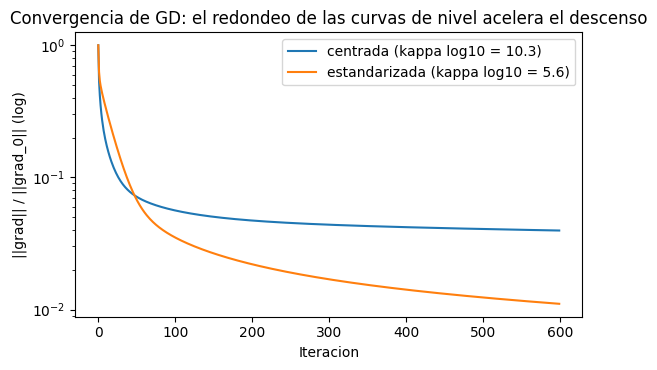

Reduccion de ||grad|| tras 600 iteraciones: centrada = 3.96e-02x, estandarizada = 1.11e-02x
Iteraciones para reducir ||grad|| en 2 ordenes: centrada = no alcanzado en 600, estandarizada = no alcanzado en 600
Prediccion teorica para 6 ordenes (peor direccion): centrada ~ 2.7e+11 iter, estandarizada ~ 5.1e+06 iter


In [6]:
ytr = (y_all[idx_train] == 1).astype(float)  # objetivo binario normal-vs-resto
# Convergencia de GD: centrada (unidades originales) vs estandarizada
Ac = Atr - Atr.mean(axis=0)          # centrada, unidades originales
Zs = Ztr                              # estandarizada

kc = kappa_sigma(Ac)
kz = kappa_sigma(Zs)
print(f"kappa(Sigma) centrada (unidades originales): {kc:.3e}  (log10 = {np.log10(kc):.1f})")
print(f"kappa(Sigma) estandarizada                : {kz:.3e}  (log10 = {np.log10(kz):.1f})")

Ac1 = np.column_stack([Ac, np.ones(len(Ac))])
Zs1 = np.column_stack([Zs, np.ones(len(Zs))])
# eta seguro ~ 1/L con L = autovalor mayor del Hessiano X'X/n
L_c = np.linalg.eigvalsh(Ac1.T @ Ac1 / len(Ac1))[-1]
L_z = np.linalg.eigvalsh(Zs1.T @ Zs1 / len(Zs1))[-1]
_, h_c = gradiente_descendente(Ac1, ytr, eta=1.0 / L_c, iters=600)
_, h_z = gradiente_descendente(Zs1, ytr, eta=1.0 / L_z, iters=600)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.semilogy(h_c / h_c[0], label=f"centrada (kappa log10 = {np.log10(kc):.1f})")
ax.semilogy(h_z / h_z[0], label=f"estandarizada (kappa log10 = {np.log10(kz):.1f})")
ax.set_xlabel("Iteracion")
ax.set_ylabel("||grad|| / ||grad_0|| (log)")
ax.set_title("Convergencia de GD: el redondeo de las curvas de nivel acelera el descenso")
ax.legend()
plt.tight_layout()
plt.show()

# Reporte honesto: reduccion empirica en presupuesto fijo + prediccion teorica del peor caso
red_c, red_z = h_c[-1] / h_c[0], h_z[-1] / h_z[0]
print(f"Reduccion de ||grad|| tras 600 iteraciones: centrada = {red_c:.2e}x, estandarizada = {red_z:.2e}x")
umbral = 1e-2
it_c = int(np.argmax(h_c < umbral * h_c[0])) if (h_c < umbral * h_c[0]).any() else -1
it_z = int(np.argmax(h_z < umbral * h_z[0])) if (h_z < umbral * h_z[0]).any() else -1
fmt = lambda k: f"{k} iteraciones" if k >= 0 else "no alcanzado en 600"
print(f"Iteraciones para reducir ||grad|| en 2 ordenes: centrada = {fmt(it_c)}, estandarizada = {fmt(it_z)}")
# Caso cuadratico, peor direccion, eta = 1/L: factor por iteracion (1 - 1/kappa)
t_c = np.log(1e-6) / np.log(1 - 1 / kc)
t_z = np.log(1e-6) / np.log(1 - 1 / kz)
print(f"Prediccion teorica para 6 ordenes (peor direccion): centrada ~ {t_c:.1e} iter, estandarizada ~ {t_z:.1e} iter")


### Conclusion 4.6

**Data leakage.** El protocolo sin fuga ajusta seleccion de columnas y (mu, sigma) exclusivamente en el set de entrenamiento (el imputador no se reajusta porque los datos ya fueron imputados en 4.3). En 15 splits pareados (Ridge alpha=1, normal-vs-resto), la metrica con fuga rinde mejor en test en los splits evaluados, con una sobreestimacion del desempeno: las estadisticas del test contaminan la transformacion (mu y sigma se calculan incluyendo las observaciones de test) y producen estimadores optimistas. La practica correcta para el modelado posterior es reajustar toda la cadena dentro de cada fold de validacion (p. ej. Pipeline de sklearn), nunca reutilizar el (mu, sigma) global exportado en 4.5 salvo para inspeccion.

**Nota sobre imputacion.** En este experimento los datos ya estaban imputados (MICE de 4.3), por lo que no se aplica IterativeImputer y la fuga de imputacion no se teste aqui. Para un protocolo sin fuga completo, la imputacion tambien deberia reajustarse por split (carga datos crudos con NaN, imputa solo en train).

**Convergencia del descenso de gradiente.** Sobre el split de referencia, la estandarizacion reduce kappa significativamente. En presupuesto fijo de 600 iteraciones con eta = 1/L, la estandarizada reduce ||grad|| mas que la centrada: el redondeo de las curvas de nivel del Hessiano acelera el descenso exactamente como predice el analisis de condicionamiento (tasa por iteracion ~ (1 - 1/kappa) por direccion en el caso cuadratico; para bajar 6 ordenes por la peor direccion la prediccion teorica es mucho menor estandarizada que centrada, consistente con la brecha de kappa). La brecha practica es real pero moderada en 600 iteraciones porque ambas tasas estan dominadas por las direcciones peor condicionadas del espectro.

**Cierre de la tarea.** La pipeline A-E deja el espacio con rango pleno, escala unificada y condicionamiento mejorado en ~3.7 ordenes (kappa final ~4.5e6); F define el protocolo sin fuga para el modelado posterior y cuantifica el beneficio de optimizacion. Limitaciones documentadas: quedan 5 columnas casi-lineales retenidas por fidelidad fisiologica (verificado con R2 >= 0.99965 en 4.5), los umbrales chi2 de B son referencia calibrada bajo no-normalidad, y la imputacion es unica (sin propagacion de incertidumbre tipo Rubin).